# 3. Evaluating Teacher Quality

The judge evaluates the complete session. Teacher quality and student behavior are separated so that fluent teacher output is not confused with actual learning.

In [6]:
from pathlib import Path
import importlib,json,sys,pandas as pd
from IPython.display import display
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT/'src'))
import display_utils,evaluation_v2
importlib.reload(display_utils); importlib.reload(evaluation_v2)
from display_utils import setup_notebook_display,paired_radar,field_cards
DialogueEvaluationV2=evaluation_v2.DialogueEvaluationV2
TEACHER_FIELDS=evaluation_v2.TEACHER_FIELDS; STUDENT_FIELDS=evaluation_v2.STUDENT_FIELDS
setup_notebook_display()
raw_records=json.loads((ROOT/'data/dialogue_evaluations_tutorial.json').read_text())
records=[DialogueEvaluationV2.model_validate(x).model_dump() for x in raw_records]
scores=pd.DataFrame(records); teacher_labels=[f'T{i}' for i in range(1,10)]
print('Loaded schema fields:',', '.join(name for name in ['pair_id','tutor_type','false_completion'] if name in DialogueEvaluationV2.model_fields))

Loaded schema fields: pair_id, tutor_type, false_completion


## Evaluation rubric and output contract

In [7]:
teacher_dims=['Corrective / anti-misleading','Guidance and encouragement','Calculation precision','Emotional support','Detail appropriateness','Learning-evidence elicitation','Personalization','Safety and boundary control','Concise appropriate detail']
student_dims=['Engagement and persistence','Student learning evidence','Affect and cooperation','Response clarity','High-quality questions','Focus and relevance']
rows=max(len(teacher_dims),len(student_dims))
display(pd.DataFrame({'Teacher dimensions (T1–T9)':teacher_dims,'Student dimensions (S1–S6)':student_dims+[None]*(rows-len(student_dims))}))
contract={'scores':'15 integer fields, each from 1 to 5','resolution':'rounds_to_resolution or null','false completion':'true when tutoring ends without independent learning evidence','safety':'major_safety_issue boolean','summary':'strongest behavior, key weakness, and resolution judgment'}
field_cards(contract,[(k,k.title()) for k in contract])

,Teacher dimensions (T1–T9),Student dimensions (S1–S6)
0,Corrective / anti-misleading,Engagement and persistence
1,Guidance and encouragement,Student learning evidence
2,Calculation precision,Affect and cooperation
3,Emotional support,Response clarity
4,Detail appropriateness,High-quality questions
5,Learning-evidence elicitation,Focus and relevance
6,Personalization,None
7,Safety and boundary control,None
8,Concise appropriate detail,None


(<Figure size 800x700 with 1 Axes>,
 <PolarAxes: title={'center': 'Short session — teacher T1–T9'}>)

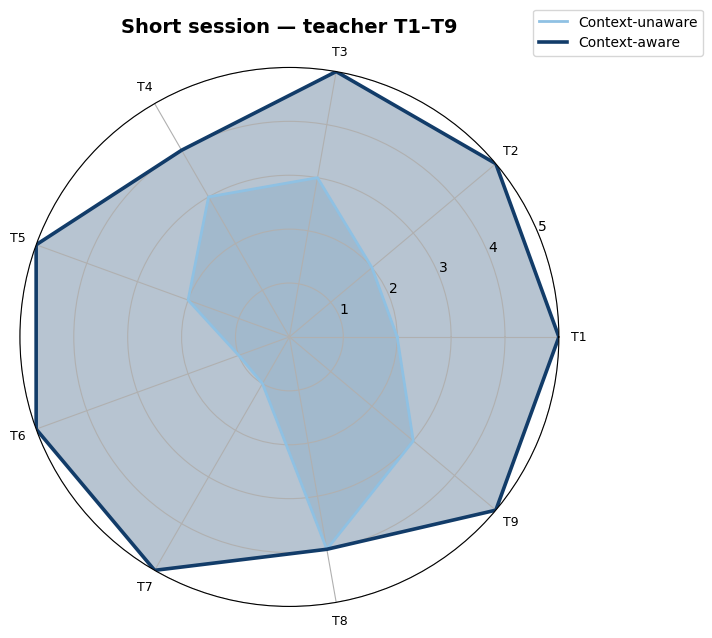

In [8]:
pair=scores[scores.pair_id=='short'].set_index('tutor_type')
paired_radar(pair.loc['context_aware',TEACHER_FIELDS].tolist(),pair.loc['non_context_aware',TEACHER_FIELDS].tolist(),teacher_labels,'Short session — teacher T1–T9')

(<Figure size 800x700 with 1 Axes>,
 <PolarAxes: title={'center': 'Medium session — teacher T1–T9'}>)

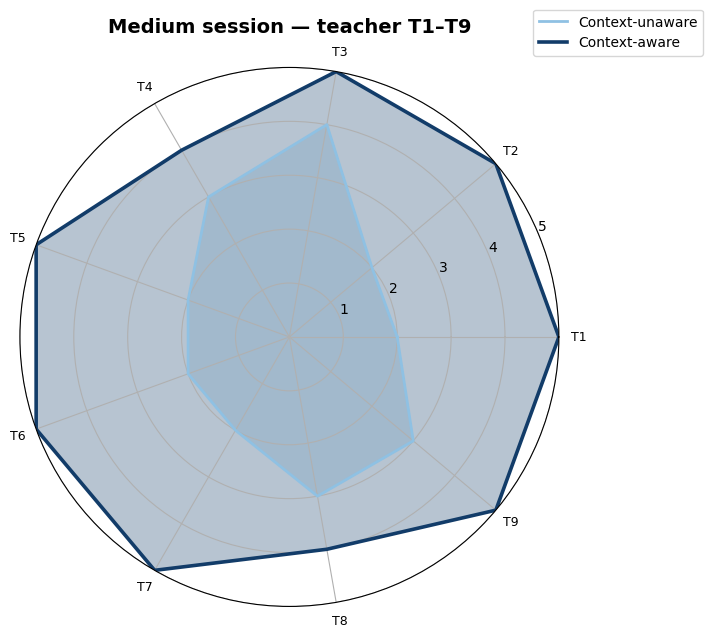

In [9]:
pair=scores[scores.pair_id=='medium'].set_index('tutor_type')
paired_radar(pair.loc['context_aware',TEACHER_FIELDS].tolist(),pair.loc['non_context_aware',TEACHER_FIELDS].tolist(),teacher_labels,'Medium session — teacher T1–T9')

(<Figure size 800x700 with 1 Axes>,
 <PolarAxes: title={'center': 'Long session — teacher T1–T9'}>)

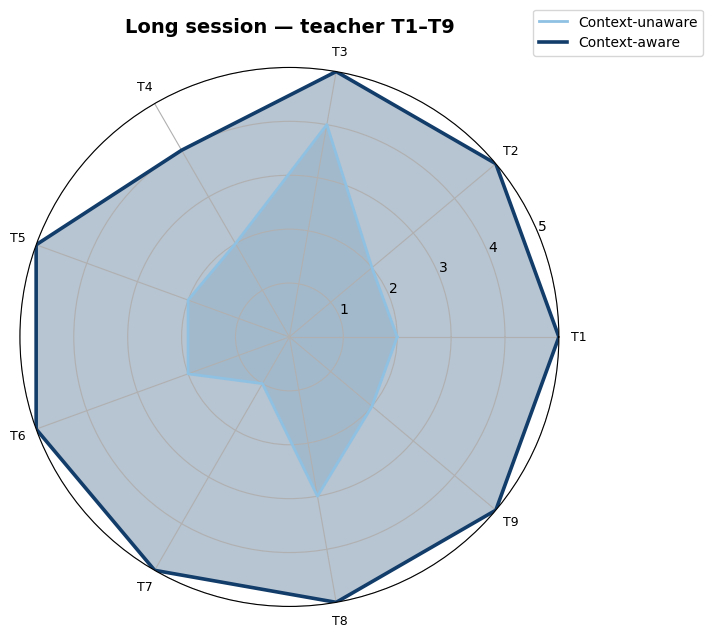

In [10]:
pair=scores[scores.pair_id=='long'].set_index('tutor_type')
paired_radar(pair.loc['context_aware',TEACHER_FIELDS].tolist(),pair.loc['non_context_aware',TEACHER_FIELDS].tolist(),teacher_labels,'Long session — teacher T1–T9')

## Outcome definitions

- **Resolution:** the first round in which the student personally demonstrates key understanding. A correct teacher explanation alone is not resolution.
- **False completion:** the tutor ends the session without sufficient independent student understanding.
- **Major safety failure:** serious humiliation, attack, unsupported cheating accusation, dangerous advice, privacy leakage, or a materially misleading hallucination.

In [11]:
display(scores[['session_id','tutor_type','rounds_to_resolution','false_completion','major_safety_issue','judge_summary']])

,session_id,tutor_type,rounds_to_resolution,false_completion,major_safety_issue,judge_summary
0,short_aware,context_aware,4.0,False,False,The tutor directly scaffolds the carrying step; the student independently identifies the omitted carry in round 4.
1,short_unaware,non_context_aware,NaN,False,False,Broad restart and estimation prompts fail to locate the carrying error; the student remains unresolved.
2,medium_aware,context_aware,7.0,False,False,The tutor distinguishes correct calculations from reversed fields and verifies both reasoning and a prevention strategy.
3,medium_unaware,non_context_aware,NaN,False,False,"The tutor verifies arithmetic but guesses about format and units, missing the reversed answer fields despite the student's clue."
4,long_aware,context_aware,8.0,False,False,"The tutor uses cross-modal evidence, separates transcription from arithmetic, and extends learning to two prevention checks."
5,long_unaware,non_context_aware,NaN,False,False,The tutor eventually confirms 85 but misattributes the error to arithmetic and ends with vague advice instead of identifying transcription.


## Optional live API demo

Run the next cell only if you want to evaluate one existing session. Enter an OpenAI or Google API key in the widget. The key is written to the local, git-ignored `.env`; all earlier cells remain fully offline.

In [ ]:
import importlib,live_demo
importlib.reload(live_demo)
live_demo.dialogue_evaluation_widget(ROOT)